## Hypothesis Testing
**H0:** mu_Female(t) = mu_Male(t)  
**H1:** mu_Female(t) ≠ mu_Male(t)  

Flanker Task EEG — Channel FC1  
Female group: 37 subjects | Male group: 25 subjects

## Imports

In [1]:
import os
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Add HT/ to path for helper modules
sys.path.insert(0, str(Path('HT').resolve()))
from f_stat_two_sample import f_stat_two_sample
from l2_stat_two_sample import l2_stat_two_sample
from z_two_sample import z_two_sample

## Set current dir to project root dir

In [2]:
def find_project_root():
    markers = [".git", "Makefile", "renv.lock", ".Rprofile"]
    path = Path.cwd()
    while path != path.parent:
        if any((path / m).exists() for m in markers):
            return path
        path = path.parent
    raise FileNotFoundError("Could not find project root")

os.chdir(find_project_root())


## Setup

In [3]:
out_dir = Path("./HT/outputs")
out_dir.mkdir(parents=True, exist_ok=True)


## Load smoothed data and split by gender

In [4]:
with open("./EDA/outputs/fd_smooth.pkl", "rb") as f:
    d = pickle.load(f)

coef_opt    = d["coef_opt"]
basis       = d["basis"]
time_vec    = d["time_vec"]
subject_ids = d["subject_ids"]

print(f"Total subjects in fd_smooth: {len(subject_ids)}")

t_fine = np.linspace(time_vec[0], time_vec[-1], 501)
B_fine = basis.evaluate(t_fine).squeeze().T
Y_eval = B_fine @ coef_opt


Total subjects in fd_smooth: 62


/tmp/ipykernel_2892069/3171454477.py:12: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the basis object instead.
  B_fine = basis.evaluate(t_fine).squeeze().T


In [5]:
female_subs = [
    'sub-001', 'sub-003', 'sub-004', 'sub-007', 'sub-009', 'sub-010',
    'sub-011', 'sub-012', 'sub-013', 'sub-014', 'sub-016', 'sub-017',
    'sub-019', 'sub-021', 'sub-022', 'sub-024', 'sub-025', 'sub-027',
    'sub-028', 'sub-030', 'sub-031', 'sub-032', 'sub-033', 'sub-034',
    'sub-035', 'sub-036', 'sub-037', 'sub-038', 'sub-039', 'sub-040',
    'sub-042', 'sub-043', 'sub-046', 'sub-053', 'sub-055', 'sub-060',
    'sub-062', 'sub-063', 'sub-064', 'sub-065', 'sub-066'
]
male_subs = [s for s in subject_ids if s not in female_subs]

female_idx = [i for i, s in enumerate(subject_ids) if s in female_subs]
male_idx   = [i for i, s in enumerate(subject_ids) if s in male_subs]

print(f"Female subjects found: {len(female_idx)}")
print(f"Male subjects found:   {len(male_idx)}")

Y_female = Y_eval[:, female_idx]
Y_male   = Y_eval[:, male_idx]


Female subjects found: 41
Male subjects found:   21


## Plot: Female vs Male group comparison

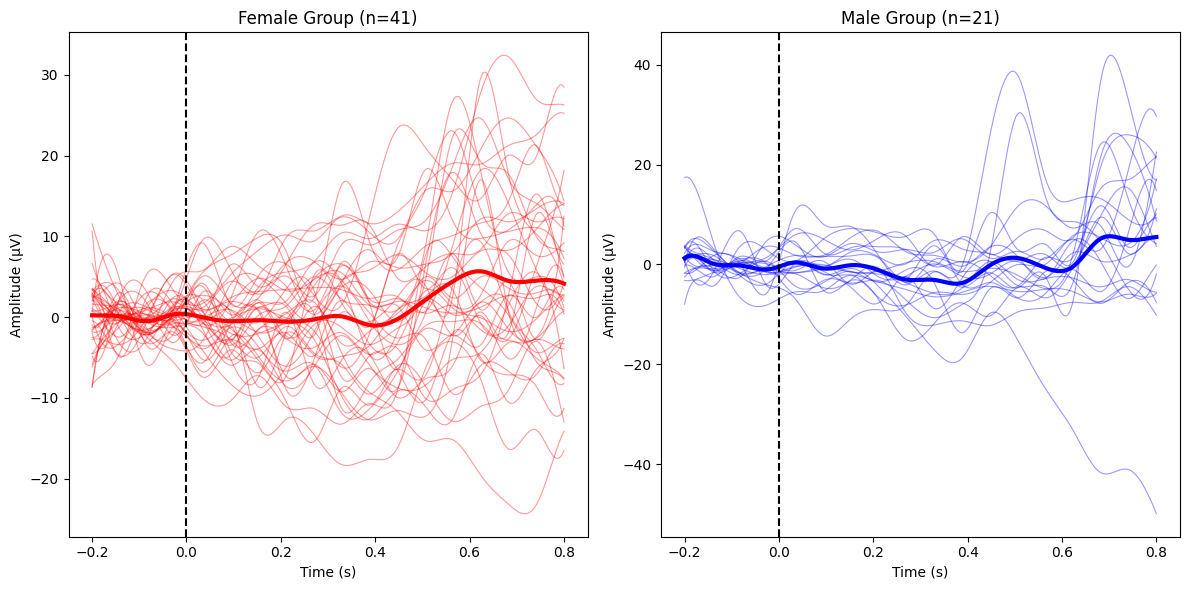

Saved: HT_05_gender_group_comparison.pdf


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].plot(t_fine, Y_female, color='red',  alpha=0.4, linewidth=0.8)
axes[0].plot(t_fine, Y_female.mean(axis=1), color='red', linewidth=3)
axes[0].axvline(0, linestyle='--', color='black')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude (µV)')
axes[0].set_title(f'Female Group (n={len(female_idx)})')

axes[1].plot(t_fine, Y_male, color='blue', alpha=0.4, linewidth=0.8)
axes[1].plot(t_fine, Y_male.mean(axis=1), color='blue', linewidth=3)
axes[1].axvline(0, linestyle='--', color='black')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Amplitude (µV)')
axes[1].set_title(f'Male Group (n={len(male_idx)})')

plt.tight_layout()
plt.savefig(out_dir / 'HT_05_gender_group_comparison.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: HT_05_gender_group_comparison.pdf')


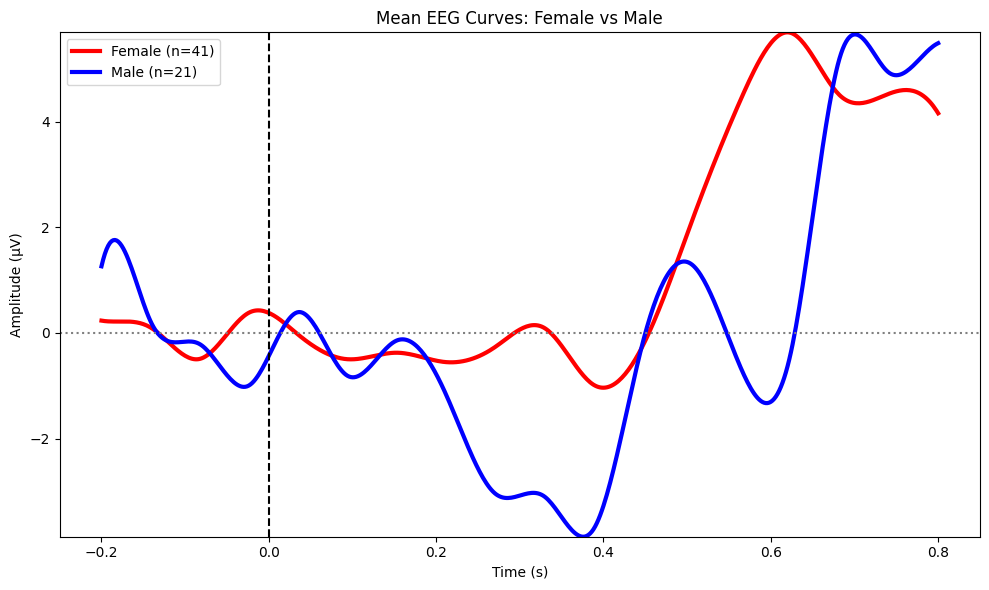

Saved: HT_06_gender_mean_comparison.pdf


In [7]:
mean_female = Y_female.mean(axis=1)
mean_male   = Y_male.mean(axis=1)
ylim = (min(mean_female.min(), mean_male.min()),
        max(mean_female.max(), mean_male.max()))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(t_fine, mean_female, color='red',  linewidth=3, label=f'Female (n={len(female_idx)})')
ax.plot(t_fine, mean_male,   color='blue', linewidth=3, label=f'Male (n={len(male_idx)})')
ax.axvline(0, linestyle='--', color='black')
ax.axhline(0, linestyle=':', color='grey')
ax.set_ylim(ylim)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (µV)')
ax.set_title('Mean EEG Curves: Female vs Male')
ax.legend()
plt.tight_layout()
plt.savefig(out_dir / 'HT_06_gender_mean_comparison.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: HT_06_gender_mean_comparison.pdf')


## Test 1: Pointwise Z-test

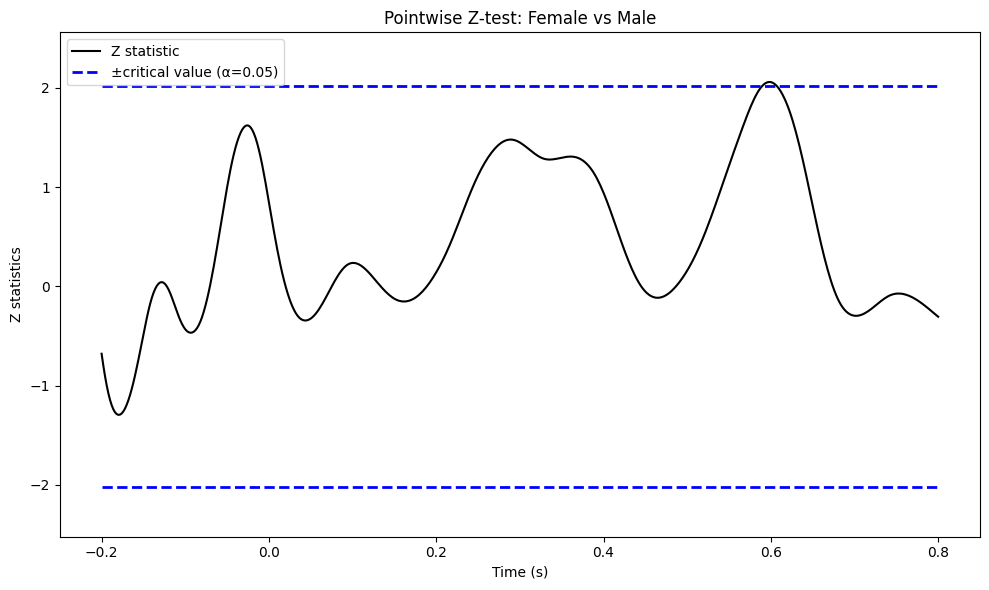

Saved: HT_07_gender_pointwise_Ztest.pdf
Critical value: 2.0227
Max |Z|: 2.0588
Time points where |Z| > critical: 8 out of 501


In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
stat_z = z_two_sample(x=Y_female, y=Y_male, t_seq=t_fine, ax=ax)
ax.set_title('Pointwise Z-test: Female vs Male')
ax.set_xlabel('Time (s)')
plt.tight_layout()
plt.savefig(out_dir / 'HT_07_gender_pointwise_Ztest.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: HT_07_gender_pointwise_Ztest.pdf')

crit = stat_z['params']['critical_value']
print(f'Critical value: {crit:.4f}')
print(f'Max |Z|: {np.max(np.abs(stat_z["statistics_pointwise"])):.4f}')
sig_points = np.sum(np.abs(stat_z['statistics_pointwise']) > crit)
print(f'Time points where |Z| > critical: {sig_points} out of {len(t_fine)}')


## Test 2: L2-norm test (naive)

In [9]:
stat_l2_naive = l2_stat_two_sample(x=Y_female, y=Y_male, t_seq=t_fine, method=1)
print(f'L2 statistic: {stat_l2_naive["statistics"]:.4f}')
print(f'p-value:      {stat_l2_naive["pvalue"]:.4f}')


L2 statistic: 37401.7198
p-value:      0.4636


## Test 3: L2-norm test (bootstrap)

In [10]:
stat_l2_boot = l2_stat_two_sample(x=Y_female, y=Y_male, t_seq=t_fine,
                                   method=2, replications=500, random_state=42)
print(f'L2 statistic: {stat_l2_boot["statistics"]:.4f}')
print(f'p-value:      {stat_l2_boot["pvalue"]:.4f}')


L2 statistic: 37401.7198
p-value:      0.2560


## Test 4: F-type test (naive)

In [11]:
stat_f_naive = f_stat_two_sample(x=Y_female, y=Y_male, t_seq=t_fine, method=1)
print(f'F statistic: {stat_f_naive["statistics"]:.4f}')
print(f'p-value:     {stat_f_naive["pvalue"]:.4f}')


F statistic: 0.8053
p-value:     0.4669


## Test 5: F-type test (bootstrap)

In [12]:
stat_f_boot = f_stat_two_sample(x=Y_female, y=Y_male, t_seq=t_fine,
                                 method=2, replications=500, random_state=42)
print(f'F statistic: {stat_f_boot["statistics"]:.4f}')
print(f'p-value:     {stat_f_boot["pvalue"]:.4f}')


F statistic: 0.8053
p-value:     0.2780


## Test 6: Permutation test

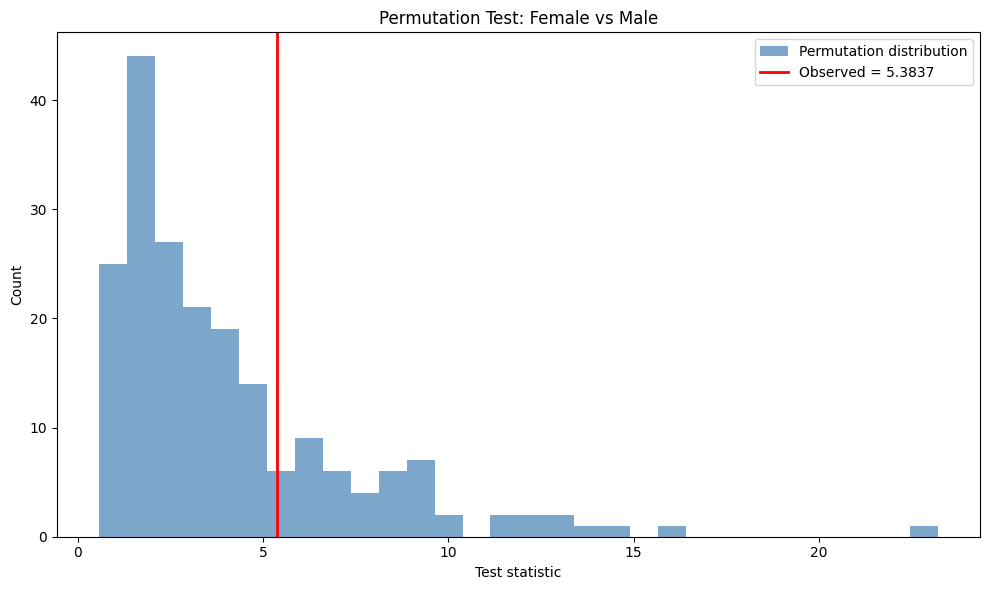

Saved: HT_08_gender_permutation_test.pdf
p-value: 0.2300


In [13]:
def tperm_fd(x, y, t_seq, replications=200, random_state=None):
    """
    Permutation test for equality of two functional means.
    Python equivalent of fda::tperm.fd().
    Test statistic: integrated squared difference of means.
    """
    if random_state is not None:
        np.random.seed(random_state)

    n = x.shape[1]
    m = y.shape[1]
    combined = np.hstack([x, y])

    def test_stat(a, b):
        diff = a.mean(axis=1) - b.mean(axis=1)
        return np.trapezoid(diff**2, t_seq)

    observed   = test_stat(x, y)
    perm_stats = np.zeros(replications)

    for i in range(replications):
        perm          = np.random.permutation(n + m)
        perm_stats[i] = test_stat(combined[:, perm[:n]], combined[:, perm[n:]])

    return {'statistic': observed, 'pval': float(np.mean(perm_stats >= observed)),
            'perm_stats': perm_stats}

stat_perm = tperm_fd(Y_female, Y_male, t_fine, replications=200, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(stat_perm['perm_stats'], bins=30, color='steelblue', alpha=0.7,
        label='Permutation distribution')
ax.axvline(stat_perm['statistic'], color='red', linewidth=2,
           label=f'Observed = {stat_perm["statistic"]:.4f}')
ax.set_xlabel('Test statistic')
ax.set_ylabel('Count')
ax.set_title('Permutation Test: Female vs Male')
ax.legend()
plt.tight_layout()
plt.savefig(out_dir / 'HT_08_gender_permutation_test.pdf', format='pdf', bbox_inches='tight')
plt.show()
print('Saved: HT_08_gender_permutation_test.pdf')
print(f'p-value: {stat_perm["pval"]:.4f}')


## Summary

In [14]:
pvals = {
    'L2-norm test (naive)':      stat_l2_naive['pvalue'],
    'L2-norm test (bootstrap)':  stat_l2_boot['pvalue'],
    'F-type test (naive)':       stat_f_naive['pvalue'],
    'F-type test (bootstrap)':   stat_f_boot['pvalue'],
    'Permutation test':          stat_perm['pval'],
}

sig_level = 0.05
print('=' * 40)
print('     HYPOTHESIS TESTING SUMMARY')
print('=' * 40)
print('H0: mu_Female(t) = mu_Male(t)')
print('H1: mu_Female(t) != mu_Male(t)')
print(f'Female group: n = {len(female_idx)}')
print(f'Male group:   n = {len(male_idx)}')
print('-' * 40)
for name, pval in pvals.items():
    print(f'{name:<35}  p = {pval:.4f}')
print('-' * 40)
all_pvals = list(pvals.values())
if all(p > sig_level for p in all_pvals):
    print('Conclusion: FAIL TO REJECT H0.')
    print('No significant difference between Female and Male groups.')
elif all(p <= sig_level for p in all_pvals):
    print('Conclusion: REJECT H0.')
    print('Significant difference between Female and Male groups.')
else:
    print('Conclusion: MIXED RESULTS.')
print('=' * 40)


     HYPOTHESIS TESTING SUMMARY
H0: mu_Female(t) = mu_Male(t)
H1: mu_Female(t) != mu_Male(t)
Female group: n = 41
Male group:   n = 21
----------------------------------------
L2-norm test (naive)                 p = 0.4636
L2-norm test (bootstrap)             p = 0.2560
F-type test (naive)                  p = 0.4669
F-type test (bootstrap)              p = 0.2780
Permutation test                     p = 0.2300
----------------------------------------
Conclusion: FAIL TO REJECT H0.
No significant difference between Female and Male groups.
